# Figure 3 | Hematopoiesis (Paul15) — scQDiff operator analysis

| Panel | What it shows |
|-------|---------------|
| **3a** | Inferred drift field — arrows follow 7MEP → Ery / Neu |
| **3b** | Local sensitivity (max real eigenvalue) peaks before bifurcation |
| **3c** | Five archetype activation profiles across pseudotime |
| **3d** | Coordination — sequential handoffs and concurrent activation |

> Three API calls replace ~500 lines of notebook code.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import scanpy as sc
import scqdiff as sqd

N_EPOCHS     = 5000
N_ARCHETYPES = 5
OUTDIR       = 'results/figure3/'
os.makedirs(OUTDIR, exist_ok=True)

print(f'scqdiff v{sqd.__version__}')

scqdiff v0.3.0


## Step 1 — Preprocessing
Normalize → HVG (2000) → PCA (50) → neighbors (k=15) → DPT from 7MEP root.

In [2]:
adata = sc.datasets.paul15()

sqd.pp.prepare_trajectory(
    adata,
    groupby = 'paul15_clusters',
    root    = '7MEP',
    n_hvg   = 2000,
    n_pcs   = 50,
    n_neighbors= 20
)

print(adata)
print(f"Pseudotime range: [{adata.obs['pseudotime'].min():.3f}, {adata.obs['pseudotime'].max():.3f}]")

AnnData object with n_obs × n_vars = 2730 × 2000
    obs: 'paul15_clusters', 'dpt_pseudotime', 'pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'iroot', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Pseudotime range: [0.000, 1.000]


## Step 2 — Fit drift field and compute archetypes

- Auto-derives pseudotime-gradient velocity prior (no RNA velocity needed)
- FiLM time-conditioning + spectral normalization
- Jacobian tensor (100 windows) + semi-NMF archetype decomposition
- Everything stored in `adata.uns['scqdiff']`

In [3]:
sqd.tl.fit_drift(
    adata,
    time_key     = 'pseudotime',
    n_archetypes = N_ARCHETYPES,
    n_epochs     = N_EPOCHS,
    vel_scale    = 2.0,
    vel_time_mode= 'flat',
)

print(f"R² = {adata.uns['scqdiff']['r2']:.3f}")
print("Top 5 genes per archetype:")
for k in range(N_ARCHETYPES):
    genes = adata.uns['scqdiff']['top_genes'].get(str(k), [])
    print(f"  A{k+1}: {', '.join(genes[:5])}")

Computing pseudotime-gradient velocity prior...
DriftField: 894,692 parameters | device=cpu | epochs=5000


Training drift field:   0%|          | 0/5000 [00:00<?, ?it/s]

Training complete. Final loss: 99.4878
Computing Jacobian tensor...


Jacobians:   0%|          | 0/100 [00:00<?, ?it/s]

Running archetype decomposition (semi-NMF)...
Done. R²=0.984 | Archetypes stored in adata.uns['scqdiff']
R² = 0.984
Top 5 genes per archetype:
  A1: Myc, Brd3, Creg1, Clic1, Tgfb1
  A2: Sfpq, Rps10, Ndufa13, Hn1, Rps11
  A3: Car1, Prkcsh, Hsp90b1, Myc, Chd4
  A4: Ndufv3, Creg1, Arpc4, Ly6c2, Nup210
  A5: Myc, Sfpq, mKIAA1027, Ifngr1, H3f3a


In [4]:
adata

AnnData object with n_obs × n_vars = 2730 × 2000
    obs: 'paul15_clusters', 'dpt_pseudotime', 'pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'iroot', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'diffmap_evals', 'scqdiff'
    obsm: 'X_pca', 'X_umap', 'X_diffmap', 'X_drift', 'X_velocity_pseudo'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

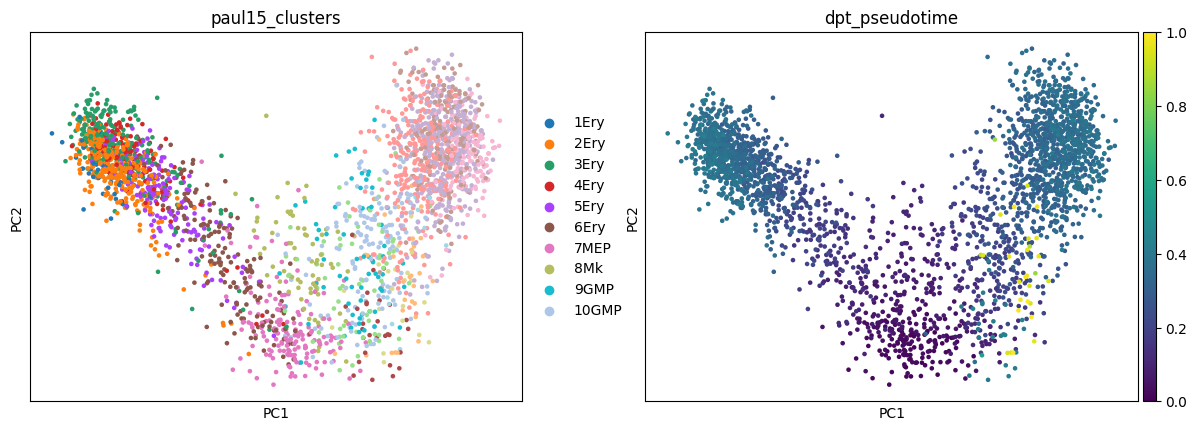

In [5]:
sc.pl.pca(adata, color=['paul15_clusters','dpt_pseudotime' ])

## Step 3 — Generate Figure 3

Saved: results/figure3/Figure3_combined.pdf


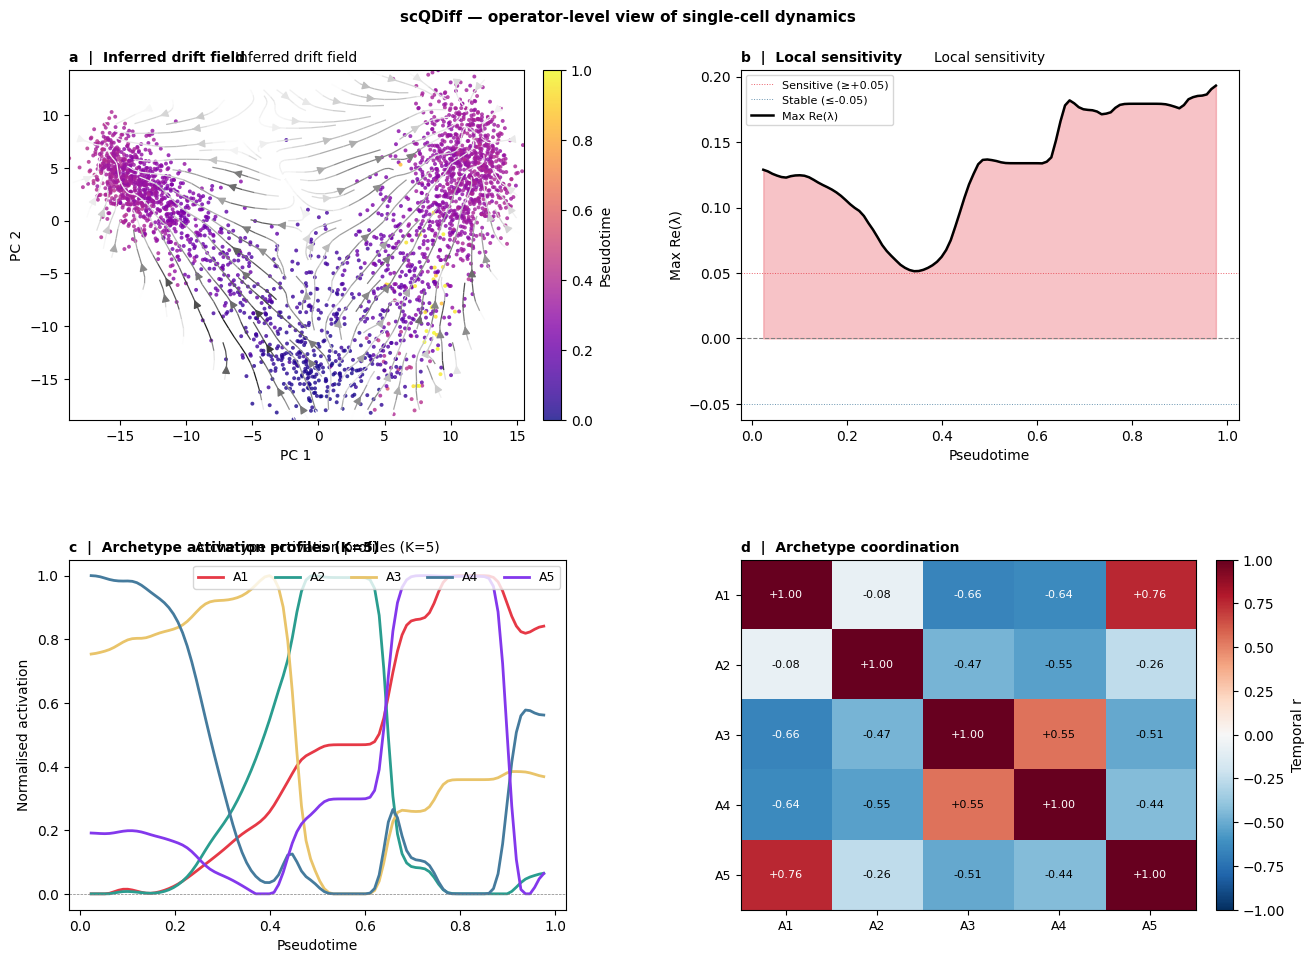

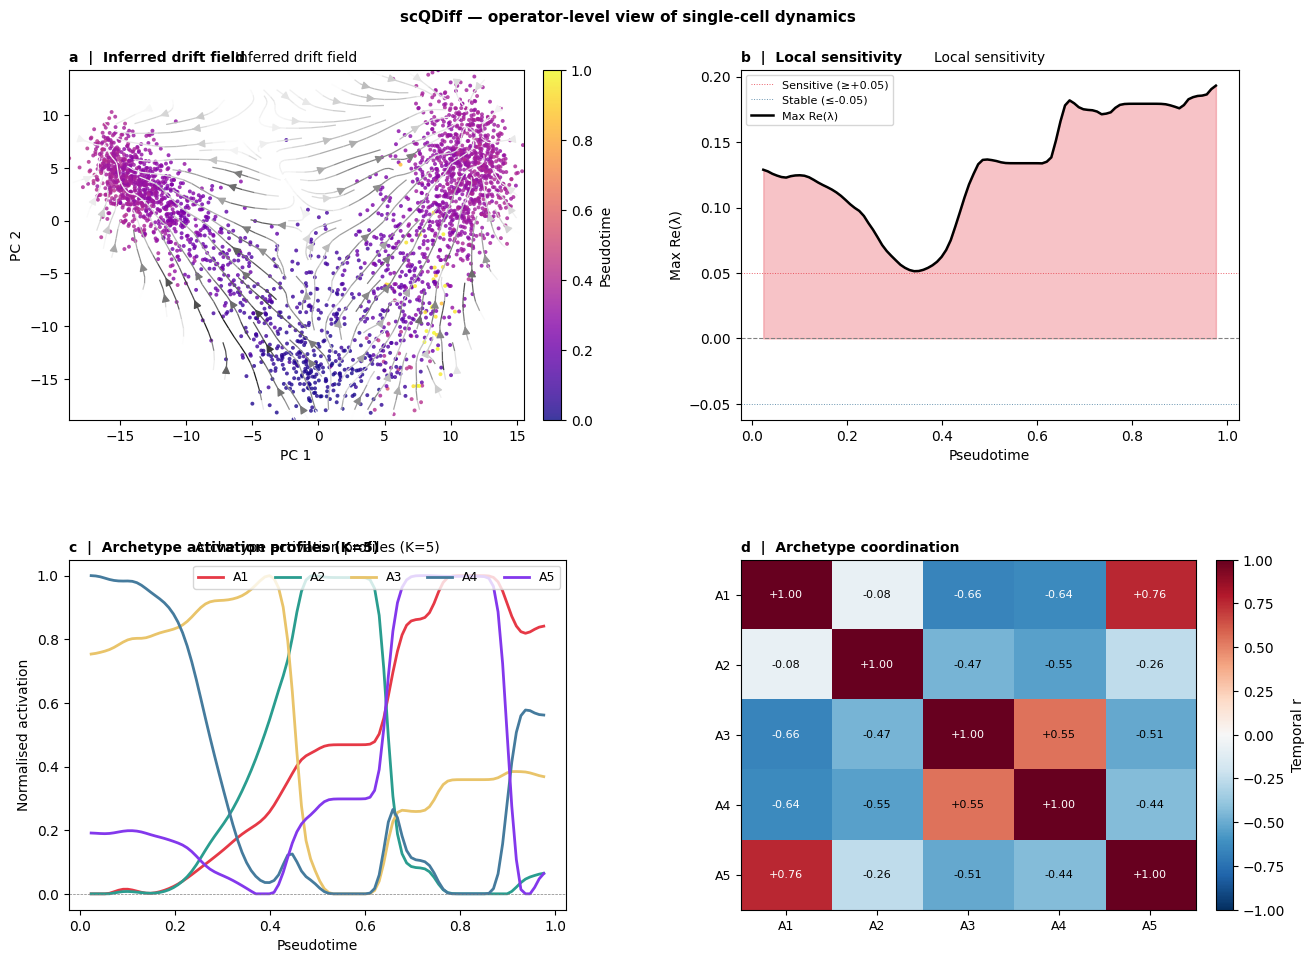

In [6]:
sqd.pl.summary_figure(
    adata,
    basis = 'X_pca',
    save  = OUTDIR + 'Figure3_combined.pdf',
)

## Individual panels (optional)

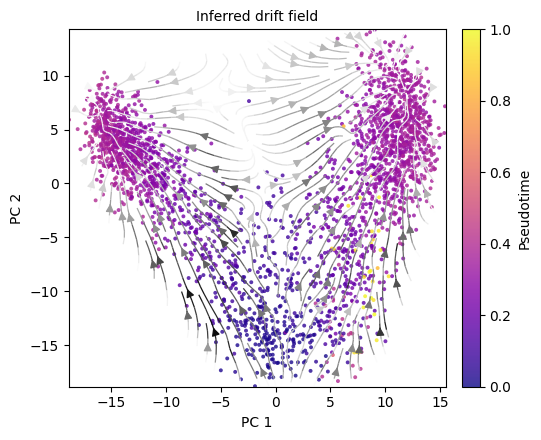

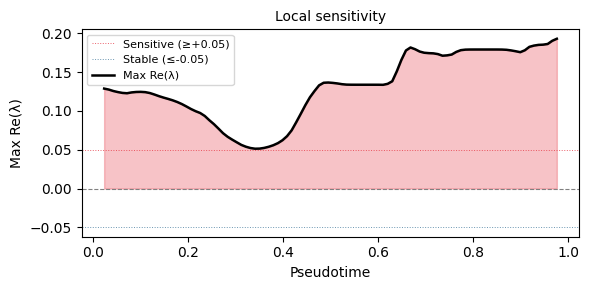

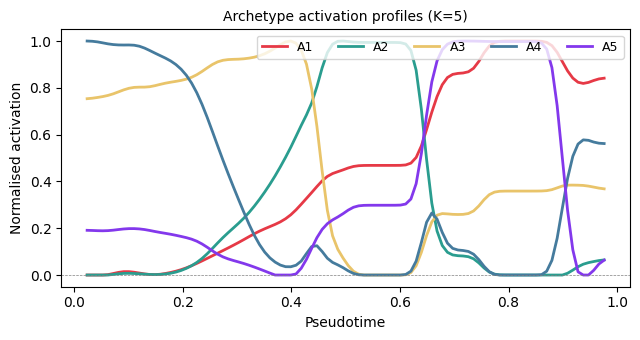

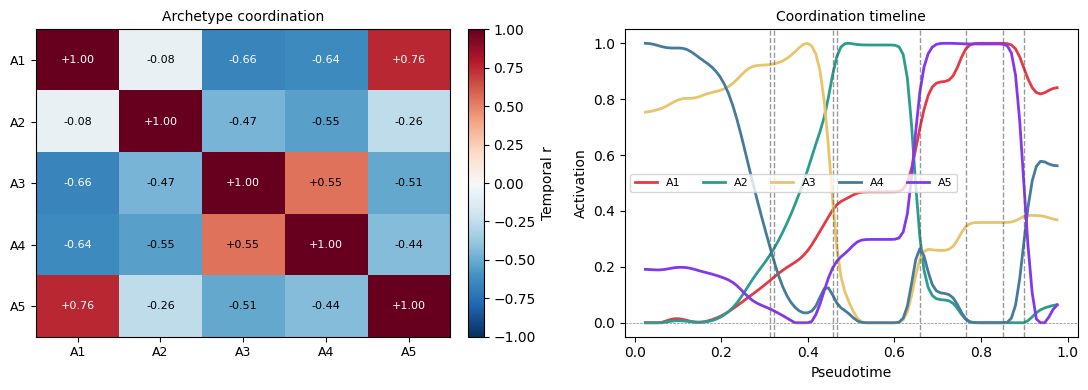

(<Axes: title={'center': 'Archetype coordination'}>,
 <Axes: title={'center': 'Coordination timeline'}, xlabel='Pseudotime', ylabel='Activation'>)

In [7]:
sqd.pl.drift_field(adata, basis='X_pca', n_grid=40,stream_density=1.5,save=OUTDIR + 'figure3a_drift.pdf')
sqd.pl.sensitivity(adata,save=OUTDIR + 'figure3b_sensitivity.pdf')
sqd.pl.archetypes(adata,save=OUTDIR + 'figure3c_archetypes.pdf')
sqd.pl.coordination(adata,save=OUTDIR + 'figure3d_coordination.pdf')

## Inspect results

In [8]:
import numpy as np

res  = adata.uns['scqdiff']
t_np = res['t_centers']
eig  = res['max_real_eig']
corr = res['corr_mat']

print(f"Peak sensitivity at pseudotime: {t_np[np.argmax(eig)]:.3f}")
print(f"R\u00b2 (reconstruction):            {res['r2']:.3f}")

labels = [f'A{k+1}' for k in range(N_ARCHETYPES)]
print('\nPairwise temporal correlations:')
print('       ' + ''.join(f' {l:>6}' for l in labels))
for i, li in enumerate(labels):
    print(f'{li:>5}  ' + ''.join(f' {corr[i,j]:+.3f}' for j in range(N_ARCHETYPES)))

Peak sensitivity at pseudotime: 0.976
R² (reconstruction):            0.984

Pairwise temporal correlations:
            A1     A2     A3     A4     A5
   A1   +1.000 -0.075 -0.663 -0.637 +0.756
   A2   -0.075 +1.000 -0.466 -0.546 -0.256
   A3   -0.663 -0.466 +1.000 +0.547 -0.515
   A4   -0.637 -0.546 +0.547 +1.000 -0.437
   A5   +0.756 -0.256 -0.515 -0.437 +1.000


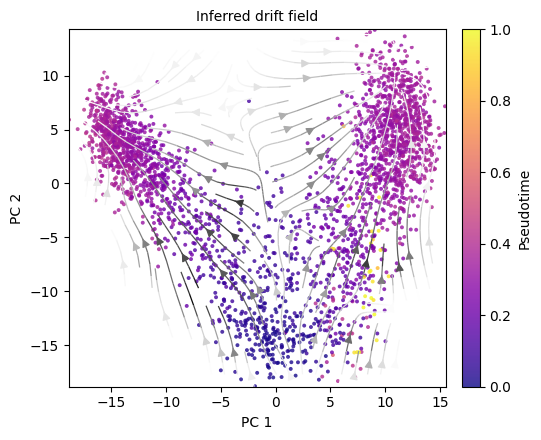

<Axes: title={'center': 'Inferred drift field'}, xlabel='PC 1', ylabel='PC 2'>

In [9]:
sqd.pl.drift_field(adata, basis='X_pca',n_grid=10,stream_density=1,save=OUTDIR + 'figure3a_drift.pdf')


In [10]:
sqd.pl.drift_field

<function scqdiff.pl._drift.drift_field(adata, key: 'str' = 'scqdiff', basis: 'str' = 'X_pca', color: 'str' = 'pseudotime', velocity_key: 'Optional[str]' = None, stream: 'bool' = True, stream_density: 'float' = 1.2, n_grid: 'int' = 30, min_cells: 'int' = 3, ax: 'Optional[plt.Axes]' = None, save: 'Optional[str]' = None, **scatter_kw)>

## Step 4 — Instability Gene Analysis

Which genes drive local instability along the hematopoiesis trajectory?

For each sensitive pseudotime window (Re(λ_max) > threshold), the eigenvector of the local Jacobian associated with the **maximum real eigenvalue** is projected to gene space via PCA loadings. Genes with the highest scores are those whose perturbation is most amplified — candidate drivers of fate decisions.

**Three panels + a ranked table:**
- Sensitivity curve with sensitive windows shaded
- Top N instability genes tracked across pseudotime
- Heatmap: mean instability score per gene × archetype

/Users/terooatt/Downloads/scQDiff/scqdiff/pl/_drift.py:414: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


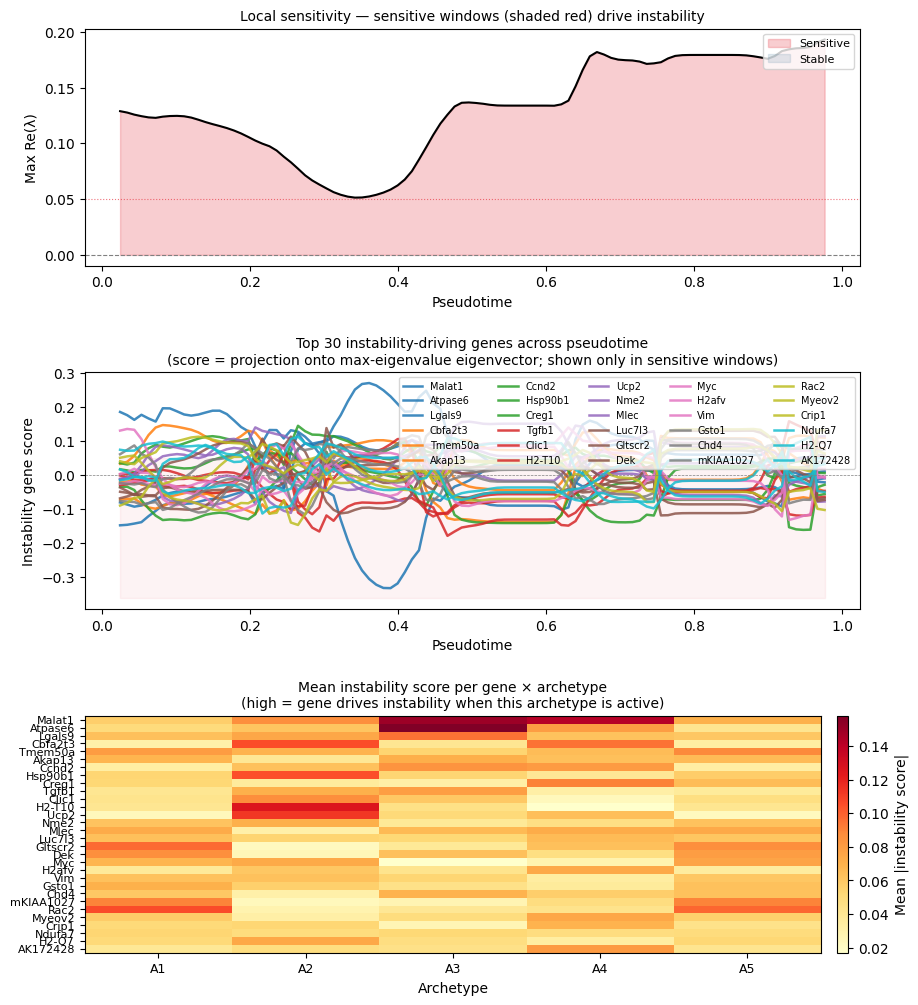

 rank      gene  mean_instability_score  peak_pseudotime primary_archetype
    1    Malat1                  0.1053            0.361                A3
    2   Atpase6                  0.0778            0.389                A3
    3    Lgals9                  0.0685            0.226                A3
    4   Cbfa2t3                  0.0679            0.082                A4
    5   Tmem50a                  0.0675            0.659                A5
    6    Akap13                  0.0625            0.947                A1
    7     Ccnd2                  0.0617            0.264                A3
    8   Hsp90b1                  0.0615            0.562                A2
    9     Creg1                  0.0592            0.947                A1
   10     Tgfb1                  0.0581            0.293                A3
   11     Clic1                  0.0579            0.928                A1
   12    H2-T10                  0.0579            0.466                A2
   13      Ucp2          

In [11]:
table = sqd.pl.instability_genes(
    adata,
    n_genes               = 30,
    sensitivity_threshold = 0.05,
    per_archetype         = True,
    save = OUTDIR + 'instability_genes.pdf',
)

In [12]:
# Save ranked table to CSV
table.to_csv(OUTDIR + 'instability_genes_table.csv', index=False)
print(table.to_string(index=False))

 rank      gene  mean_instability_score  peak_pseudotime primary_archetype
    1    Malat1                  0.1053            0.361                A3
    2   Atpase6                  0.0778            0.389                A3
    3    Lgals9                  0.0685            0.226                A3
    4   Cbfa2t3                  0.0679            0.082                A4
    5   Tmem50a                  0.0675            0.659                A5
    6    Akap13                  0.0625            0.947                A1
    7     Ccnd2                  0.0617            0.264                A3
    8   Hsp90b1                  0.0615            0.562                A2
    9     Creg1                  0.0592            0.947                A1
   10     Tgfb1                  0.0581            0.293                A3
   11     Clic1                  0.0579            0.928                A1
   12    H2-T10                  0.0579            0.466                A2
   13      Ucp2          

## Regulatory Network Inference

Links instability genes to upstream TF regulators using a signed TF-target network (CollecTRI → TRRUST → built-in). Scores each TF on six metrics:

| Metric | What it captures |
|--------|------------------|
| Weighted out-degree | Total instability explained by TF targets |
| Mean target instability | Quality: few sharp targets > many weak ones |
| Regulon enrichment | Hypergeometric overlap with top instability genes |
| Branch specificity | Entropy-based archetype preference |
| Database confidence | Mean edge weight in the source network |
| Pseudotime lead | TF expression peak before target instability peak |

**Figure 5 (hybrid network):** solid edges = database-confirmed links; dashed edges = de novo co-instability pairs inferred from Jacobian eigenvector structure.

In [19]:
# Infer upstream TF regulators
df_reg = sqd.tl.infer_regulators(
    adata,
    organism = 'mouse',
    min_targets = 3,
    n_top = 50,
)
df_reg.to_csv(OUTDIR + 'regulators.csv', index=False)
print(df_reg[['regulator','weighted_score','mean_instability',
              'n_targets','enrichment_score','peak_archetype']].head(50).to_string(index=False))

[network] TRRUST v2 loaded — 7,057 edges
[forward] Scoring regulators against 2000 genes...
  Top 5: Sp1, Nfkb1, Trp53, Jun, Nfe2l2
  De novo edges: 3205
regulator  weighted_score  mean_instability  n_targets  enrichment_score peak_archetype
      Sp1          0.7905            0.0181         57             0.622             A5
    Nfkb1          0.5525            0.0138         51             0.035             A5
    Trp53          0.3808            0.0128         40             0.153             A1
      Jun          0.3149            0.0151         25             0.104             A4
   Nfe2l2          0.2742            0.0231         13             2.260             A3
     Rela          0.2732            0.0145         26             0.036             A5
    Stat3          0.2646            0.0191         18             0.317             A5
      Myc          0.2502            0.0265         11             0.943             A2
     Spi1          0.2148            0.0154         18

Saved: results/figure3/regulator_summary.pdf


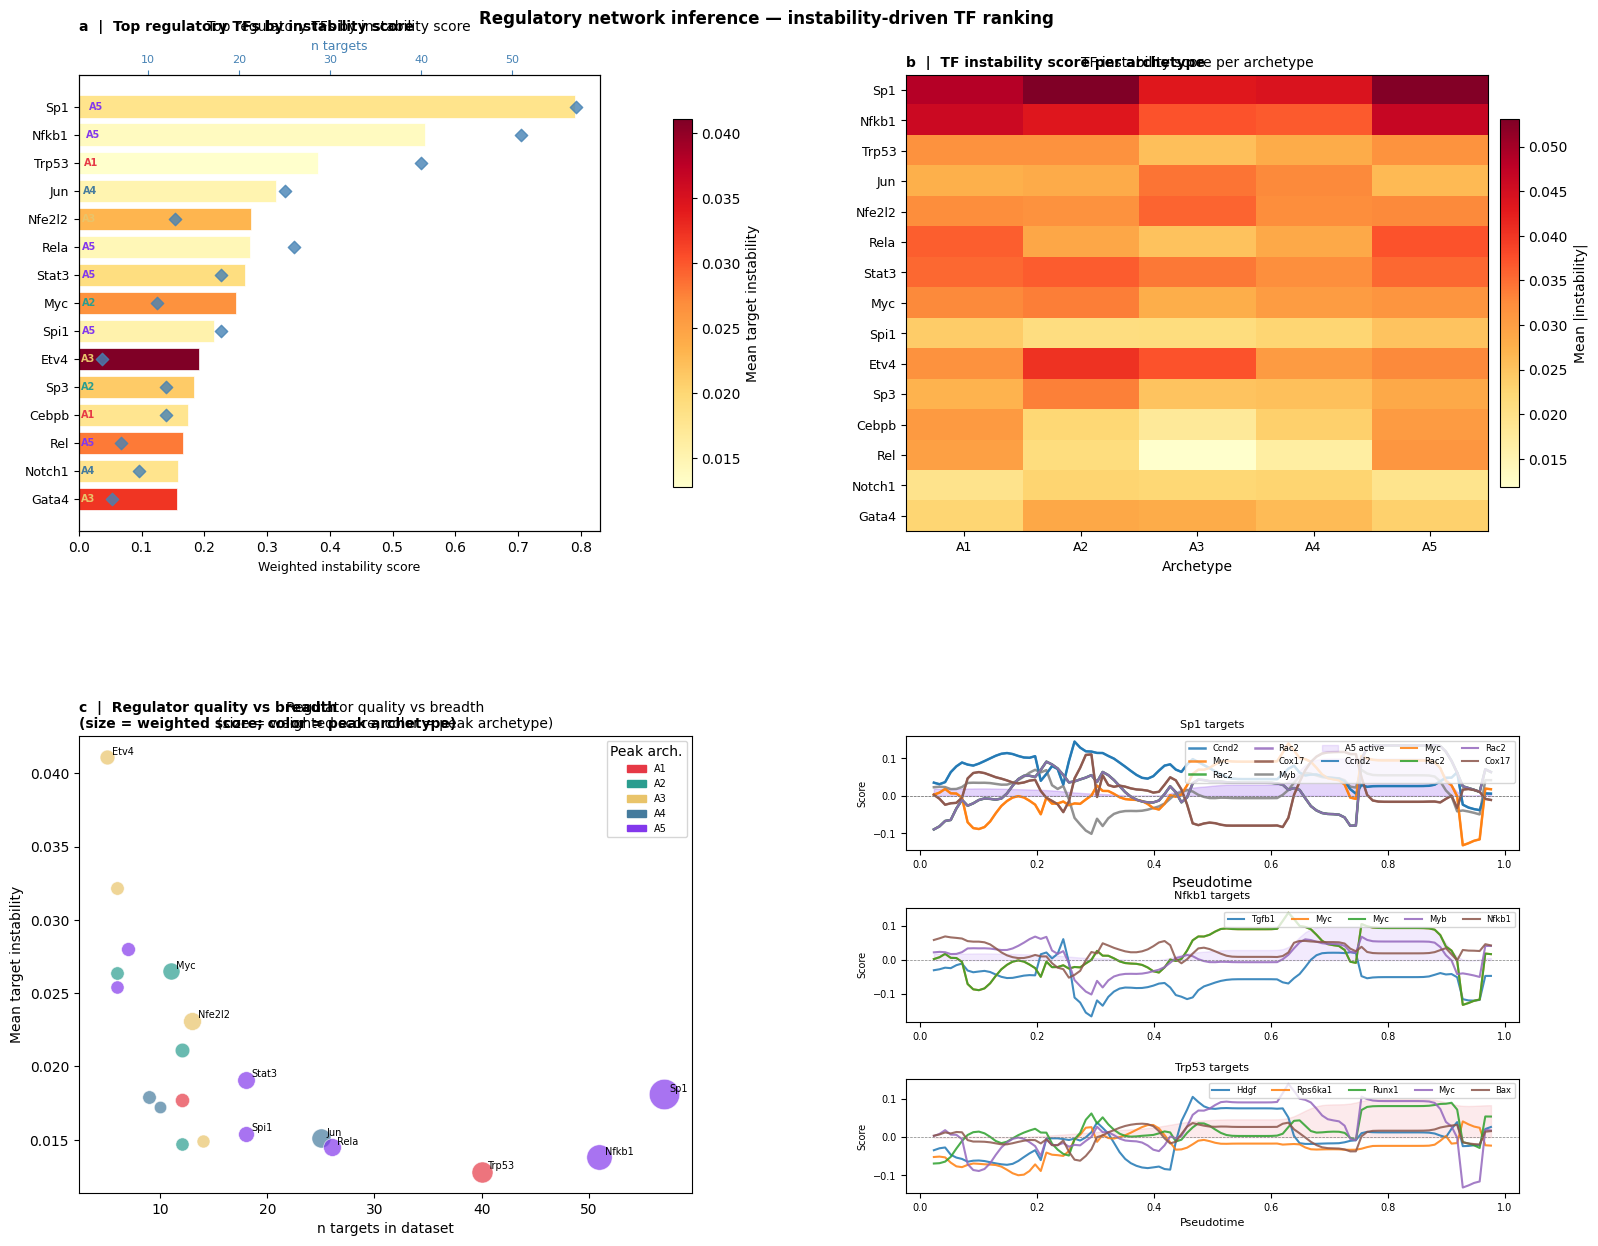

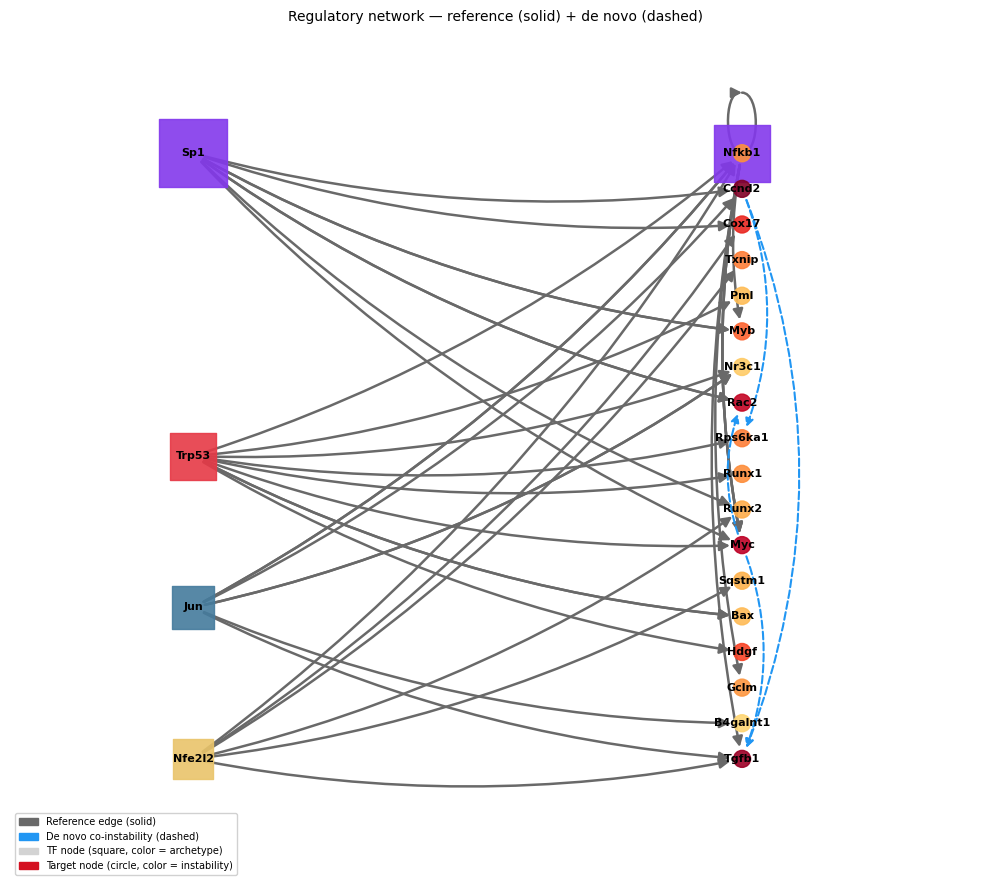

<Axes: title={'center': 'Regulatory network — reference (solid) + de novo (dashed)'}>

In [14]:
# Four-panel summary (bar + heatmap + scatter + profiles)
sqd.pl.regulator_summary(adata, save=OUTDIR + 'regulator_summary.pdf')

# Hybrid network graph (solid = reference, dashed = de novo co-instability)
sqd.pl.regulator_network(
    adata,
    n_tfs     = 5,
    n_targets = 6,
    n_denovo  = 4,
    save      = OUTDIR + 'regulator_network.pdf',
)

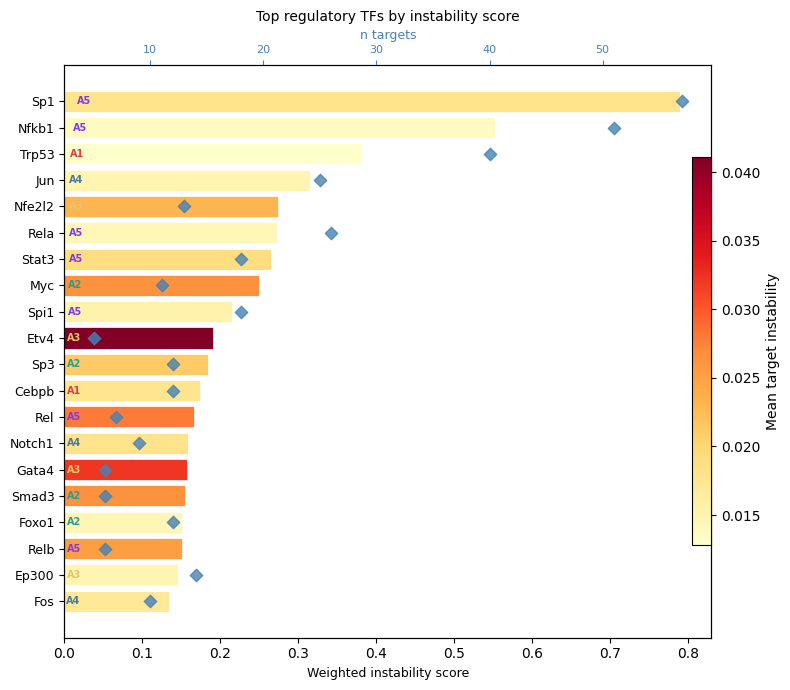

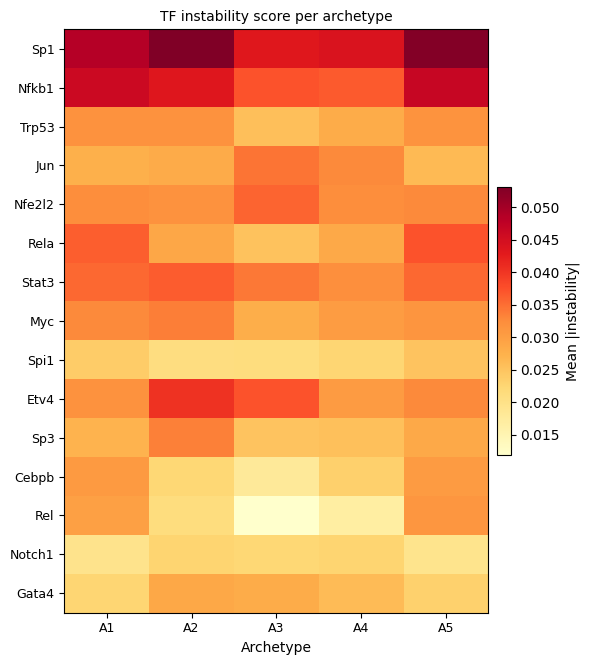

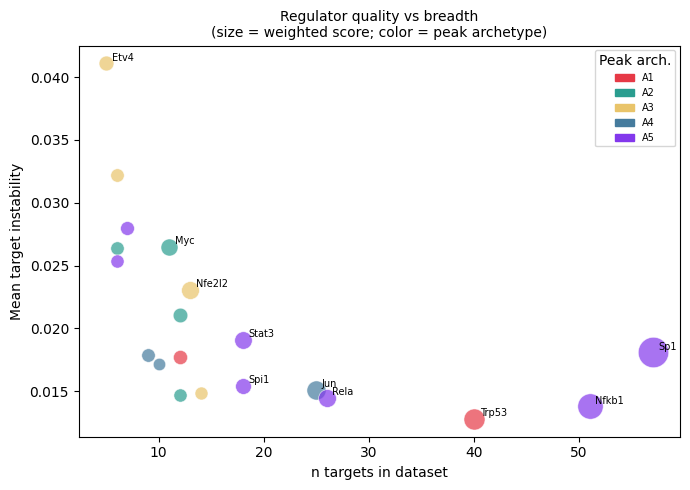

/Users/terooatt/Downloads/scQDiff/scqdiff/pl/_regulators.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


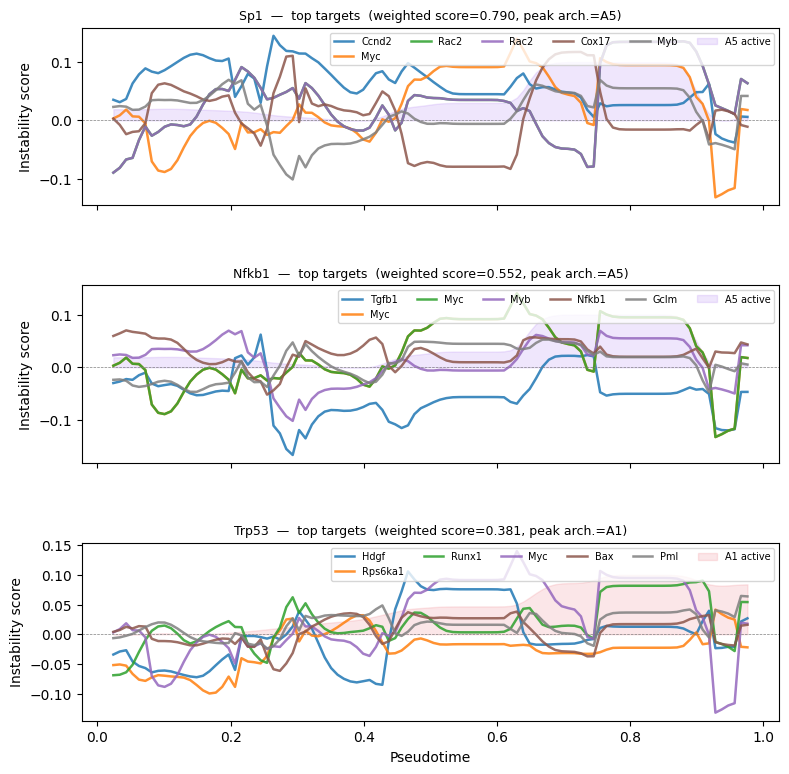

array([<Axes: title={'center': 'Sp1  —  top targets  (weighted score=0.790, peak arch.=A5)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Nfkb1  —  top targets  (weighted score=0.552, peak arch.=A5)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Trp53  —  top targets  (weighted score=0.381, peak arch.=A1)'}, xlabel='Pseudotime', ylabel='Instability score'>],
      dtype=object)

In [15]:
# Individual panels
sqd.pl.regulator_barplot(adata, n_show=20, save=OUTDIR + 'reg_barplot.pdf')
sqd.pl.regulator_heatmap(adata, n_show=15, save=OUTDIR + 'reg_heatmap.pdf')
sqd.pl.regulator_scatter(adata, n_label=10, save=OUTDIR + 'reg_scatter.pdf')
sqd.pl.regulator_profiles(adata, n_tfs=3,  save=OUTDIR + 'reg_profiles.pdf')